In [142]:
import torch
from src.model_unet import UNet,UnetGenerator
from src.DWM.data_setup import get_test_loader,get_watermark_img
from src.DWM.engine import *
from src.DWM.deep_watermark import *
import os

name = rf'uni_256_binary_2'
model_path = rf'runs2\fine_tune_cancat\{name}/best.pt'
extractor_path = rf'runs2\watermark_cocat\{name}/E/best.pt'

folder_name = rf'fine_tune_result\{name}'
os.makedirs(folder_name,exist_ok=True)


wm_size = (256,256)
round_wm = True
wm_channel = 1
watermark_acc = calculate_bcr
watermark_loss = nn.MSELoss()
adversarial_loss = nn.BCELoss()
task_loss = nn.BCELoss()
img_wm = get_watermark_img(rf'datasets\watermark_img\yazd_university.png',
                           wm_size,
                           convert='L',
                           round=round_wm)
val_path = rf'datasets\sub_gray_dataset\test'
dataloader = get_test_loader(val_path,
                            batch_size=16,
                            imgsize=(256,256),
                            convert='RGB')



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sk = torch.ones((1,)+wm_size)

model_H = UnetGenerator(input_nc=3,output_nc=3).to(device)
model_D = D_Watermark().to(device)
model_E = Extraction(wh=wm_size,
                        input_Eb=1,
                        output_Eb=1,
                        WH=(256,256),
                        input_Ea=3,
                        output_nc=wm_channel,
                        input_inception=8).to(device)


In [143]:
def accuracy_fn(y_pred,Y):
    temp = torch.round(y_pred)
    acc = 1 - torch.mean(input=temp.to(torch.int) ^ Y.to(torch.int),dtype=torch.float)
    
    return  acc
def test_wm(test_dataloader,
            img_wm,
            secret_key,
            model_H: torch.nn.Module,
            model_E: torch.nn.Module,
            content_loss,
            task_loss,
            accuracy_fn,
            calculate_watermark,
            device):

    wloss_list,tloss_list = [],[]
    wacc_list,tacc_list = [],[]
    # put model in eval mode
    model_H.eval() 
    model_E.eval()

    # Turn on inference context manager
    with torch.inference_mode(): 

        val_desc = f'test:'
        with tqdm(test_dataloader, desc=val_desc,
                  bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}') as test_tqdm:

            for i,(input_img, target_img) in enumerate(test_tqdm):
            
                watermark_batch = img_wm.unsqueeze(0).repeat(input_img.size(0), 1, 1, 1)
                secret_key_batch = secret_key.unsqueeze(0).repeat(input_img.size(0), 1, 1, 1)
                
                input_img, target_img = input_img.to(device), target_img.to(device)
                watermark_batch,secret_key_batch = watermark_batch.to(device),secret_key_batch.to(device)
                
                wm_zero = torch.rand_like(watermark_batch).to(device)
                secret_x = torch.rand_like(secret_key_batch).to(device)

               
                # 1. Forward pass
                # input_h = torch.cat([input_img,watermark_batch],dim=1)
                generated_imgs = model_H(input_img)
                
                # 2. Calculate loss and accuracy
                g_task = task_loss(generated_imgs, target_img)
                tloss_list.append(g_task.cpu().item())
                acc_task = accuracy_fn(generated_imgs, target_img)
                tacc_list.append(acc_task.cpu().item())

                ## Wloss1 = l1loss(E(H(x),k),w)
                watermark_extract = model_E(generated_imgs,secret_key_batch)
                w_loss1 = content_loss(watermark_extract,watermark_batch)
                ## Wloss2 = l1loss(E(x,k),wz)
                w_loss2 = content_loss(model_E(target_img,secret_key_batch),wm_zero)
                ## Wloss3 = l1loss(E(H(x),kx),wz)
                w_loss3 = content_loss(model_E(generated_imgs,secret_x),wm_zero)

                w_loss = w_loss1 + w_loss2 + 0.5*w_loss3
                wloss_list.append(w_loss.cpu().item())
                w_acc = calculate_watermark(watermark_batch,watermark_extract)
                wacc_list.append(w_acc.cpu().item())
                
                test_tqdm.set_description(
                    f'{val_desc} tloss:{np.mean(tloss_list):.3f} tacc:{np.mean(tacc_list):.3f} wloss:{np.mean(wloss_list):.3f} wacc:{np.mean(wacc_list):.3f}')

                if i == 0:

                    plt.imshow(np.transpose(generated_imgs[0].detach().cpu().numpy(),(1,2,0)))
                    plt.axis('off')
                    plt.savefig(rf'{folder_name}/output.png',bbox_inches='tight')
                    plt.show()

                    if watermark_extract.shape[1] == 1:
                        watermark_extract = watermark_extract[0,0].detach().cpu().numpy()
                        if round_wm:
                            watermark_extract = np.round(watermark_extract)
                        plt.imshow(watermark_extract,cmap='gray')
                    else:
                        plt.imshow(np.transpose(watermark_extract[0].detach().cpu().numpy(),(1,2,0)))
                
                    plt.axis('off')
                    plt.savefig(rf'{folder_name}/watermark.png',bbox_inches='tight')
                    plt.show()
    



                    
                
    # Calculate loss and accuracy per epoch and print out what's happening
    return np.mean(tloss_list),np.mean(tacc_list),np.mean(wloss_list),np.mean(wacc_list)

In [144]:
def load_model(path,model):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['state_dict'])

    return model

#### load model

In [145]:
model_H = load_model(model_path,model_H)
model_E = load_model(extractor_path,model_E)


test: tloss:0.560 tacc:0.661 wloss:0.200 wacc:0.910:   0%|          | 0/2 [00:00<?, ?it/s]

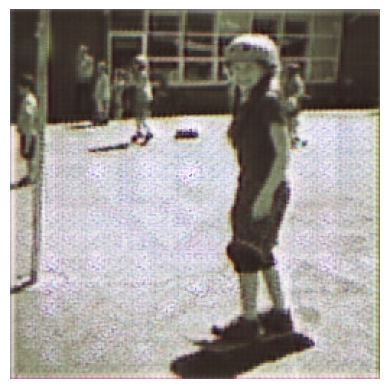

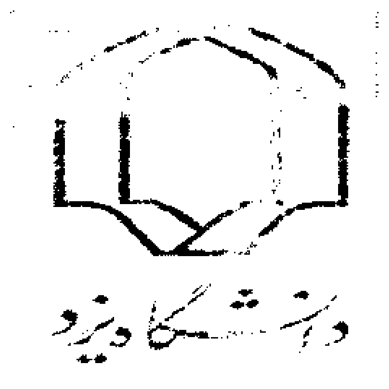

test: tloss:0.567 tacc:0.655 wloss:0.201 wacc:0.909: 100%|██████████| 2/2 [00:00<00:00,  2.62it/s]


In [146]:


atloss,atacc,awloss,awacc = test_wm(dataloader,
                                    img_wm,
                                    sk,
                                    model_H,
                                    model_E,
                                    watermark_loss,
                                    task_loss,
                                    accuracy_fn,
                                    watermark_acc,
                                    device)


In [147]:
atloss,atacc,awloss,1-awacc

(0.5666632652282715,
 0.6552558839321136,
 0.20081498473882675,
 0.09088706970214844)